In [13]:
import pandas as pd
import os
import sklearn as sk
import numpy as np

In [5]:
df = pd.read_csv("~/Documents/GitHub/Allstate-1A-predicting-auto-claims-severity/data/allstate_claims_data.csv")

In [6]:
df.shape

(188318, 132)

In [16]:
df_filesize = os.path.getsize(os.path.expanduser("~/Documents/GitHub/Allstate-1A-predicting-auto-claims-severity/data/allstate_claims_data.csv"))
df_filesize

70025339

Schema and integrity checks:


,value
shape_matches_expected,True
column_order_matches_expected,True
id_is_unique,True
missing_cells,0
duplicate_rows,0
continuous_values_in_0_to_1,True
loss_is_finite_and_positive,True


Target summary in original loss units:


,loss
count,188318.000000
mean,3037.337686
std,2904.086186
min,0.670000
25%,1204.460000
50%,2115.570000
75%,3864.045000
90%,6401.743000
95%,8508.536500
99%,13981.203000


Categorical fields: 116 | Continuous fields: 14


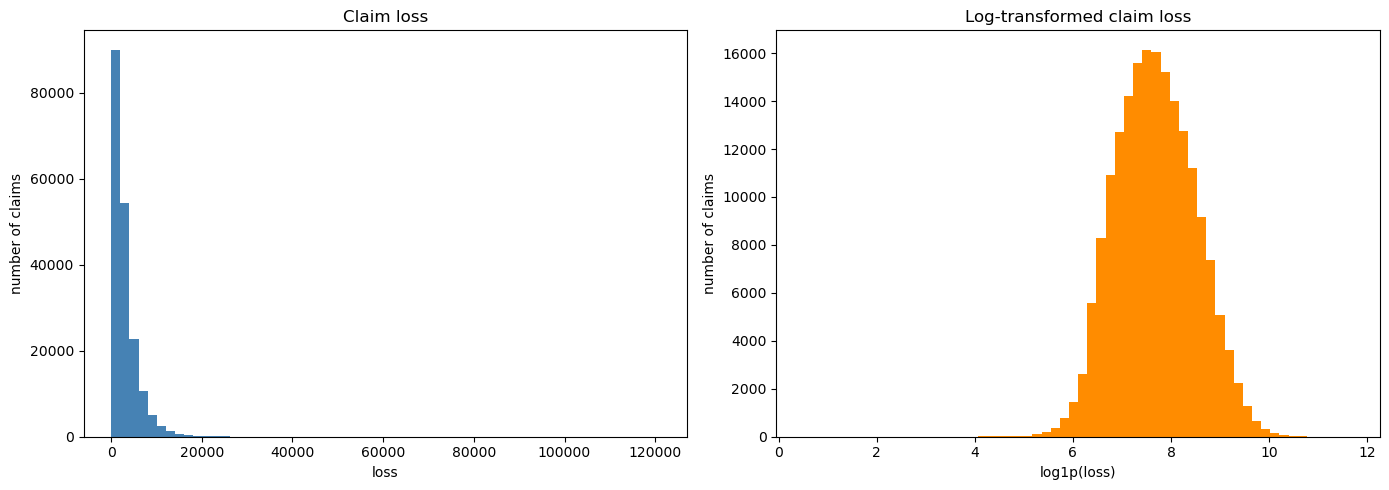

Highest-cardinality anonymous categorical fields:


,unique_levels,most_common_count,most_common_share
cat116,326,21061,0.111837
cat110,131,25305,0.134374
cat109,84,152918,0.812020
cat113,61,26191,0.139079
cat112,51,25148,0.133540
cat115,23,43866,0.232936
cat107,20,47310,0.251224
cat105,20,76493,0.406191
cat101,19,106721,0.566706
cat114,19,131693,0.699312


Continuous fields ranked by absolute Pearson association with loss:


,unique_values,minimum,maximum,mean,std,pearson_loss,spearman_loss
cont2,33,0.001149,0.862654,0.507188,0.207202,0.141528,0.080066
cont7,5632,0.069503,1.000000,0.484970,0.178450,0.119799,0.054928
cont3,76,0.002634,0.944251,0.498918,0.202105,0.111053,0.068353
cont11,326,0.035321,0.998742,0.493511,0.209737,0.099806,0.054323
cont12,328,0.036232,0.998484,0.493150,0.209427,0.098724,0.053624
cont6,2573,0.012683,0.997162,0.490945,0.205273,0.040967,0.019697
cont4,112,0.176921,0.954297,0.491812,0.211292,-0.035831,-0.027878
cont8,201,0.236880,0.980200,0.486437,0.199370,0.030508,0.027495
cont10,174,0.000000,0.994980,0.498066,0.185877,0.020236,0.003042
cont14,18740,0.179722,0.844848,0.495717,0.222488,0.019298,0.001667


In [19]:
# First-pass data quality and target profile
import numpy as np

id_columns = ["id"]
cat_columns = [f"cat{i}" for i in range(1, 117)]
cont_columns = [f"cont{i}" for i in range(1, 15)]
expected_columns = id_columns + cat_columns + cont_columns + ["loss"]

schema_checks = pd.Series({
    "shape_matches_expected": df.shape == (188318, 132),
    "column_order_matches_expected": df.columns.tolist() == expected_columns,
    "id_is_unique": df["id"].is_unique,
    "missing_cells": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "continuous_values_in_0_to_1": bool(df[cont_columns].apply(lambda column: column.between(0, 1).all()).all()),
    "loss_is_finite_and_positive": bool(np.isfinite(df["loss"]).all() and (df["loss"] > 0).all()),
})

loss_summary = df["loss"].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).to_frame("loss")
loss_summary.loc["skewness"] = df["loss"].skew()

print("Schema and integrity checks:")
display(schema_checks.to_frame("value"))
print("Target summary in original loss units:")
display(loss_summary)
print("Categorical fields:", len(cat_columns), "| Continuous fields:", len(cont_columns))
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["loss"], bins=60, color="steelblue")
axes[0].set_title("Claim loss")
axes[0].set_xlabel("loss")
axes[0].set_ylabel("number of claims")
axes[1].hist(np.log1p(df["loss"]), bins=60, color="darkorange")
axes[1].set_title("Log-transformed claim loss")
axes[1].set_xlabel("log1p(loss)")
axes[1].set_ylabel("number of claims")
plt.tight_layout()
plt.show()

categorical_inventory = pd.DataFrame({
    "unique_levels": df[cat_columns].nunique(dropna=False),
    "most_common_count": df[cat_columns].apply(lambda column: column.value_counts(dropna=False).iloc[0]),
    "most_common_share": df[cat_columns].apply(lambda column: column.value_counts(dropna=False).iloc[0] / len(column)),
}).sort_values("unique_levels", ascending=False)

continuous_inventory = pd.DataFrame({
    "unique_values": df[cont_columns].nunique(),
    "minimum": df[cont_columns].min(),
    "maximum": df[cont_columns].max(),
    "mean": df[cont_columns].mean(),
    "std": df[cont_columns].std(),
    "pearson_loss": df[cont_columns].corrwith(df["loss"], method="pearson"),
    "spearman_loss": df[cont_columns].corrwith(df["loss"], method="spearman"),
}).sort_values("pearson_loss", key=lambda values: values.abs(), ascending=False)

print("Highest-cardinality anonymous categorical fields:")
display(categorical_inventory.head(10))
print("Continuous fields ranked by absolute Pearson association with loss:")
display(continuous_inventory)

In [20]:
# Categorical-field support and target summaries
rare_level_threshold = 20

categorical_support = []
for column in cat_columns:
    counts = df[column].value_counts(dropna=False)
    categorical_support.append({
        "field": column,
        "levels": counts.size,
        "minimum_level_support": int(counts.min()),
        "median_level_support": float(counts.median()),
        "most_common_support": int(counts.iloc[0]),
        "most_common_share": float(counts.iloc[0] / len(df)),
        "levels_below_threshold": int((counts < rare_level_threshold).sum()),
    })

categorical_support = pd.DataFrame(categorical_support).sort_values(
    ["levels", "levels_below_threshold"], ascending=[False, False]
)

print(f"Rare-level threshold: fewer than {rare_level_threshold} claims")
print("Fields with the most categorical levels and rare levels:")
display(categorical_support.head(15))

# Summarize raw loss by level for selected fields; categories remain nominal labels.
def level_loss_summary(column, minimum_support=100):
    summary = (
        df.groupby(column, dropna=False)["loss"]
        .agg(support="size", mean_loss="mean", median_loss="median", std_loss="std")
        .assign(
            q1_loss=df.groupby(column, dropna=False)["loss"].quantile(0.25),
            q3_loss=df.groupby(column, dropna=False)["loss"].quantile(0.75),
        )
    )
    summary["iqr_loss"] = summary["q3_loss"] - summary["q1_loss"]
    return summary.loc[summary["support"] >= minimum_support].sort_values("mean_loss", ascending=False)

selected_fields = ["cat116", "cat110", "cat109"]
for column in selected_fields:
    print(f"{column}: supported levels ranked by mean loss")
    display(level_loss_summary(column).head(15))

field_mean_ranges = []
for column in cat_columns:
    level_summary = level_loss_summary(column)
    if len(level_summary) >= 2:
        field_mean_ranges.append({
            "field": column,
            "supported_levels": len(level_summary),
            "lowest_mean_loss": level_summary["mean_loss"].min(),
            "highest_mean_loss": level_summary["mean_loss"].max(),
            "mean_loss_range": level_summary["mean_loss"].max() - level_summary["mean_loss"].min(),
        })

print("Fields with the largest supported differences in mean loss:")
display(pd.DataFrame(field_mean_ranges).sort_values("mean_loss_range", ascending=False).head(15))

Rare-level threshold: fewer than 20 claims
Fields with the most categorical levels and rare levels:


,field,levels,minimum_level_support,median_level_support,most_common_support,most_common_share,levels_below_threshold
115,cat116,326,1,35.0,21061,0.111837,143
109,cat110,131,1,29.0,25305,0.134374,52
108,cat109,84,1,36.0,152918,0.812020,37
112,cat113,61,1,1463.0,26191,0.139079,16
111,cat112,51,30,1331.0,25148,0.133540,0
114,cat115,23,1,315.0,43866,0.232936,6
104,cat105,20,1,158.0,76493,0.406191,7
106,cat107,20,2,1432.0,47310,0.251224,3
100,cat101,19,1,2762.0,106721,0.566706,6
113,cat114,19,1,250.0,131693,0.699312,6


cat116: supported levels ranked by mean loss


,support,mean_loss,median_loss,std_loss,q1_loss,q3_loss,iqr_loss
cat116,,,,,,,
LV,298,6542.849530,3838.395,7819.745719,1921.9400,8497.6250,6575.6850
LD,137,5924.279927,3145.270,7190.391856,1684.8300,7402.7800,5717.9500
KL,280,5060.263500,3228.900,5234.732046,1823.3000,5845.7125,4022.4125
FX,149,4891.501141,3066.980,5164.761025,1701.4600,5850.5900,4149.1300
GX,595,4844.316739,2644.170,5435.795985,1314.8900,6046.4450,4731.5550
KP,251,4785.839960,2312.770,11025.155161,1270.9250,4653.9050,3382.9800
GU,591,4757.071134,3134.550,4531.240444,1641.0900,5985.3000,4344.2100
HN,1302,4679.315829,2977.290,4773.651857,1581.3350,5757.8725,4176.5375
JX,184,4674.847174,2730.940,5005.096359,1705.0650,5359.5800,3654.5150


cat110: supported levels ranked by mean loss


,support,mean_loss,median_loss,std_loss,q1_loss,q3_loss,iqr_loss
cat110,,,,,,,
EM,176,4427.839375,2621.495,4569.922817,1351.6075,5807.4800,4455.8725
AC,2611,3669.949717,2567.850,3293.724765,1405.4650,4818.3550,3412.8900
CI,1066,3566.819325,2313.195,3727.467200,1263.3975,4393.4350,3130.0375
CL,25305,3523.730538,2285.550,3782.265174,1277.1900,4324.2800,3047.0900
EE,1185,3509.414194,2275.860,3459.709248,1320.2500,4477.4100,3157.1600
EF,1159,3285.088723,2262.150,3010.123588,1273.6350,4146.9050,2873.2700
CJ,153,3206.171634,2020.400,3184.413487,1109.5600,4049.7100,2940.1500
DH,120,3196.956667,2498.310,2440.765537,1293.1000,4418.4675,3125.3675
BT,16365,3180.054736,2149.620,3069.936992,1200.4600,4085.0200,2884.5600


cat109: supported levels ranked by mean loss


,support,mean_loss,median_loss,std_loss,q1_loss,q3_loss,iqr_loss
cat109,,,,,,,
CL,178,4416.924494,2621.495,4553.953552,1345.6425,5834.6800,4489.0375
R,149,3356.650000,2696.880,2409.568516,1324.3000,4858.9800,3534.6800
BI,152918,3146.284932,2141.130,3076.370083,1211.8075,3987.5875,2775.7800
M,446,3144.497377,2145.915,2698.155926,1237.8150,4450.9725,3213.1575
AT,200,3003.640300,2673.630,1845.505927,1501.4350,4241.4250,2739.9900
AR,208,2923.483462,2549.950,1762.287818,1357.6975,4388.7150,3031.0175
G,1353,2893.434945,2305.310,2062.924370,1294.6500,4032.6000,2737.9500
F,124,2864.180887,2566.800,1829.156460,1237.3925,4145.1375,2907.7450
AS,159,2669.944025,1898.610,2135.050363,1128.2650,3574.1150,2445.8500


Fields with the largest supported differences in mean loss:


,field,supported_levels,lowest_mean_loss,highest_mean_loss,mean_loss_range
54,cat57,2,2919.869699,10239.967773,7320.098074
94,cat101,13,2454.139844,8993.138439,6538.998596
82,cat89,3,2908.944342,8213.293627,5304.349285
6,cat7,2,2908.944342,8195.078524,5286.134183
109,cat116,124,1712.065656,6542.849530,4830.783874
96,cat103,9,2814.648335,7276.575963,4461.927628
107,cat114,11,2070.594386,6385.025760,4314.431374
99,cat106,12,2591.411299,6771.240543,4179.829244
98,cat105,11,2612.922630,6631.494759,4018.572129
72,cat79,4,2469.844946,6311.832058,3841.987112
